# Probabilidad de completar el album con 140 sobres

Parametros reales del album:

- Estampas del album: `N = 980`.
- Estampas por sobre: `S = 7`.
- Sobres comprados: `M = 140`.
- Simulaciones: `R = 250000`.
- Semilla: `2026`.
- Precio sobre individual: `Q9.50`.
- Precio caja de 104 sobres: `Q975.00`.

Se calcula la probabilidad sin intercambio y, como referencia adicional, con intercambio `K=4`.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 2026
N = 980
S = 7
R = 250_000
M = 140

PRECIO_SOBRE = 9.50
PRECIO_CAJA = 975.00
SOBRES_POR_CAJA = 104

costo_individual = M * PRECIO_SOBRE
costo_una_caja_mas_sobres = PRECIO_CAJA + (M - SOBRES_POR_CAJA) * PRECIO_SOBRE


## Funcion de simulacion

Para reducir la carga, la simulacion guarda cuantas estampas distintas tiene el album. Si hay `c` estampas coleccionadas, el numero de estampas nuevas en el siguiente sobre sigue una distribucion hipergeometrica. Despues de cada sobre se aplican todos los canjes posibles de repetidas por estampas faltantes.

Cuando `k=None`, el escenario es sin intercambio. Cuando `k=4`, cada 4 repetidas acumuladas producen una estampa faltante.


In [8]:
def simular_probabilidad_completar(n, s, r, m, k=None, semilla=2026):
    rng = np.random.default_rng(semilla)
    coleccionadas = np.zeros(r, dtype=np.int16)
    repetidas = np.zeros(r, dtype=np.int16)

    for _ in range(m):
        activos = coleccionadas < n
        idx = np.flatnonzero(activos)
        if idx.size == 0:
            break

        nuevas = rng.hypergeometric(n - coleccionadas[idx], coleccionadas[idx], s)
        duplicadas = s - nuevas
        coleccionadas[idx] += nuevas.astype(np.int16)

        if k is not None:
            repetidas[idx] += duplicadas.astype(np.int16)
            canjes = np.minimum(repetidas[idx] // k, n - coleccionadas[idx])
            coleccionadas[idx] += canjes.astype(np.int16)
            repetidas[idx] -= (canjes * k).astype(np.int16)

    completado = coleccionadas >= n
    return {
        "probabilidad": completado.mean(),
        "exitos": int(completado.sum()),
        "coleccionadas": coleccionadas,
        "faltantes": n - coleccionadas,
    }


In [9]:
resultados = {
    "Sin intercambio": simular_probabilidad_completar(N, S, R, M, k=None, semilla=SEMILLA),
    "Intercambio K=4": simular_probabilidad_completar(N, S, R, M, k=4, semilla=SEMILLA),
}

print(f"Sobres comprados: {M}")
print(f"Costo si se compran todos individuales: Q{costo_individual:,.2f}")
print(f"Costo con 1 caja + 36 sobres individuales: Q{costo_una_caja_mas_sobres:,.2f}")
print()
for etiqueta, resultado in resultados.items():
    print(etiqueta)
    print(f"  Exitos: {resultado['exitos']} de {R}")
    print(f"  Probabilidad estimada: {resultado['probabilidad']:.4f}")
    print(f"  Faltantes promedio: {resultado['faltantes'].mean():.4f}")
    print(f"  Faltantes mediana: {np.median(resultado['faltantes']):.0f}")
    print(f"  Minimo de estampas coleccionadas: {resultado['coleccionadas'].min()}")


Sobres comprados: 140
Costo si se compran todos individuales: Q1,330.00
Costo con 1 caja + 36 sobres individuales: Q1,317.00

Sin intercambio
  Exitos: 0 de 250000
  Probabilidad estimada: 0.0000
  Faltantes promedio: 359.2556
  Faltantes mediana: 359
  Minimo de estampas coleccionadas: 578
Intercambio K=4
  Exitos: 0 de 250000
  Probabilidad estimada: 0.0000
  Faltantes promedio: 289.5210
  Faltantes mediana: 290
  Minimo de estampas coleccionadas: 658


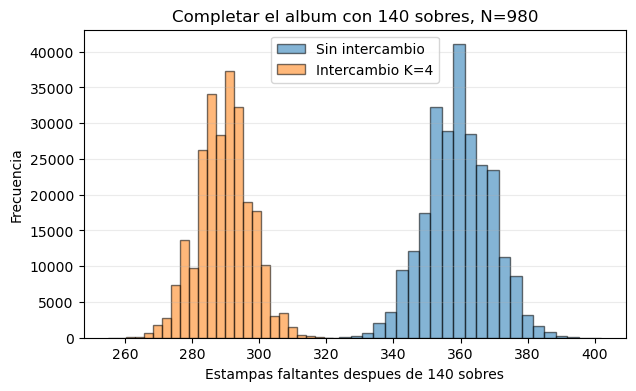

In [10]:
plt.figure(figsize=(7, 4))
for etiqueta, resultado in resultados.items():
    plt.hist(resultado["faltantes"], bins=25, alpha=0.55, edgecolor="black", label=etiqueta)

plt.xlabel("Estampas faltantes despues de 140 sobres")
plt.ylabel("Frecuencia")
plt.title("Completar el album con 140 sobres, N=980")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## Respuesta

Con `140` sobres, la probabilidad estimada de completar el album sin intercambio fue `0.0000`, con `0` exitos en `250000` simulaciones. En promedio faltaron `359.2556` estampas.

Con intercambio `K=4`, la probabilidad estimada tambien fue `0.0000`, con `0` exitos en `250000` simulaciones. En promedio faltaron `289.5210` estampas.

Costo si se compran `140` sobres individuales: `140 x Q9.50 = Q1330.00`.

Si se permite combinar caja y sobres individuales, `1` caja mas `36` sobres individuales cuesta `Q975.00 + 36 x Q9.50 = Q1317.00`.

Nota: una probabilidad simulada de `0.0000` significa que no se observaron exitos en estas `250000` simulaciones; no es una prueba matematica de imposibilidad absoluta.


## Revisión de consistencia

Con `140` sobres se compran exactamente `140×7 = 980` estampas, el mismo número que contiene el álbum. Para completar con canjes `K=4`, si aparece cualquier repetida, cuatro repetidas solo producen una nueva estampa por canje, así que no se recupera una por una la pérdida causada por las repetidas.

Usando el mismo chequeo: `T = 980`, y se necesitaría

`U >= ceil((4×980 - 980)/3) = 980`.

Es decir, habría que obtener naturalmente las `980` estampas distintas, sin ninguna repetida. En una revisión con `250000` pruebas, el número de estampas distintas sin canje estuvo entre `578` y `663`, muy lejos de `980`. Por eso la probabilidad estimada sigue siendo `0.0000`, incluso con intercambio `K=4`.
